In [7]:

import os
print(os.getcwd())
import sys
sys.path.append('/media/chronos/Storage/natalie/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL')


/media/chronos/Storage/natalie/HW/DEEP_LEARN_PROJECT


In [5]:
input_file = 'list.txt'     # Change this to your input filename
output_file = 'fsm_t1_images.txt'       # New filtered list

with open(input_file, 'r') as f:
    lines = f.readlines()

# Filter lines containing 'fsm_t1'
filtered_lines = [line for line in lines if 'fsm_t1' in line]

# Save filtered lines to output file
with open(output_file, 'w') as f:
    f.writelines(filtered_lines)

print(f"Saved {len(filtered_lines)} lines to {output_file}")


Saved 38 lines to fsm_t1_images.txt


In [6]:
import numpy as np

data = np.load("/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz/fsm_t1_50ww.npz")

# List all arrays stored in the .npz file
print(data.files)

# For each array (assuming 'image' is a key, or use the actual key shown in your file)
arr = data["vol"]  # or replace "image" with the actual key
print("Shape:", arr.shape)
print("Number of elements:", arr.size)
print("Data type:", arr.dtype)

['vol', 'seg']
Shape: (256, 256, 256)
Number of elements: 16777216
Data type: float32


training

In [27]:
%run -i voxelmorph_extension_DL/scripts/train.py --img-list 'fsmt1_short.txt'  --epochs 2

Epoch 1/2 - 0.4872 sec/step - loss: 2.4004e+03  (2.4004e+03, 4.9349e-04)
Epoch 2/2 - 0.4919 sec/step - loss: 2.3020e+03  (2.3020e+03, 2.3341e-02)


registration

In [ ]:
%run -i voxelmorph_extension_DL/scripts/register.py --moving converted_npz/fsm_pd_54jc.npz --fixed converted_npz/fsm_pd_30gy.npz --moved warped_integrated.npz --model models/0002.pt --gpu 0

In [50]:
import matplotlib.pyplot as plt

# Helper functions.
def normalize(x):
  x -= x.min()
  return x / x.max()


def show(im, title=None):
    im = np.asarray(im).reshape((256, 256, 256))
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    slices = im[:, 125, :], im[:, :, 127], im[127, :, :].T
    for im_slice, ax in zip(slices, axes):
        ax.imshow(im_slice, cmap='gray')
        ax.set_axis_off()

    if title:
        axes[1].text(0.50, 1.05, title, ha='center', transform=axes[1].transAxes, size=14)


def load_volume(path):
    nii_img = np.load(path)
    nii_img = nii_img["vol"]
    return nii_img


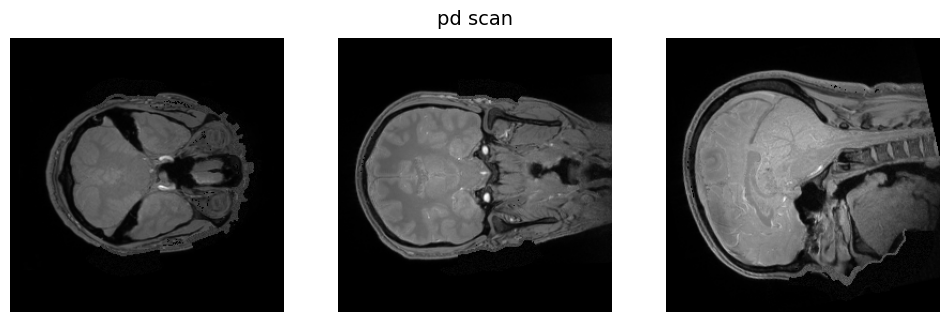

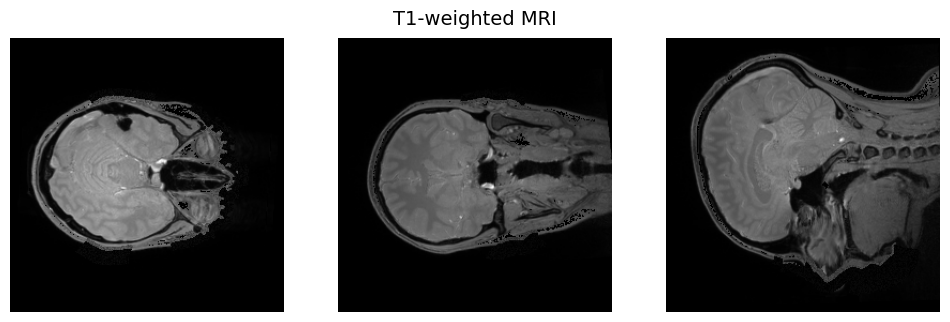

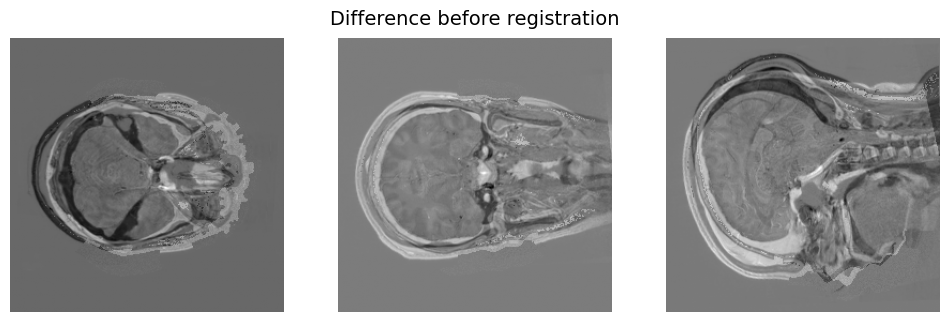

In [48]:
pd = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz/fsm_pd_30gy.npz')
t1 = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz/fsm_pd_54jc.npz')
before = normalize(pd) - normalize(t1)

show(pd, title='pd scan')
show(t1, title='T1-weighted MRI')
show(before, title='Difference before registration')

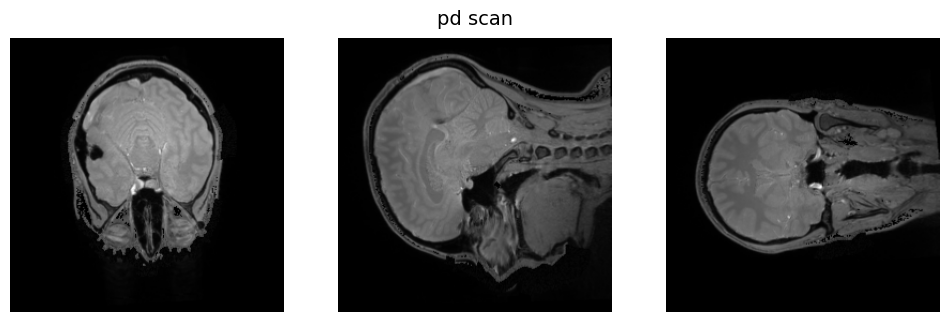

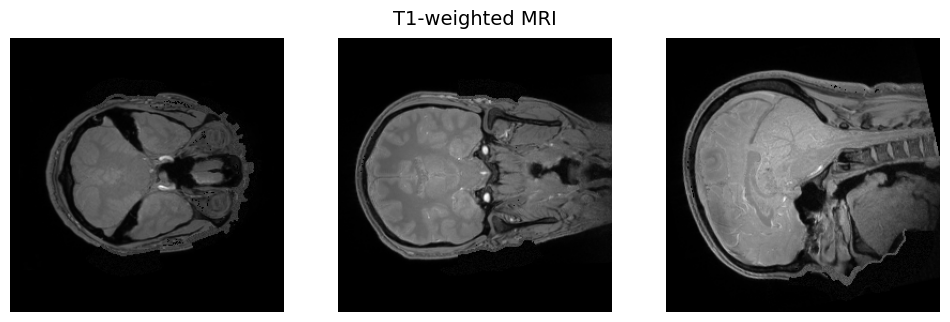

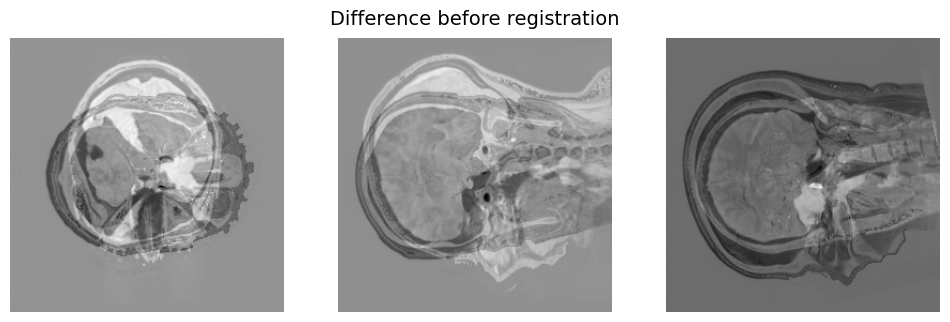

In [56]:
pd = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/warped_integrated.npz')
t1 = load_volume('/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/converted_npz/fsm_pd_30gy.npz')
before = normalize(pd) - normalize(t1)

show(pd, title='pd scan')
show(t1, title='T1-weighted MRI')
show(before, title='Difference before registration')

inference

Epoch 1/1 - 0.4885 sec/step - loss: 2.3406e+03  (2.3406e+03, 5.4073e-04)
